# AM01 Phase 2 Experiments

Notebook Colab incrementale per verificare le ipotesi emerse dalla prima analisi dei risultati.

Obiettivi:
1. confrontare soglie `best_f1` e soglie label-free su validation normale;
2. verificare stabilità multi-seed dei modelli principali;
3. capire se AAE migliora con `lambda_adv` più debole o latent più ampio;
4. valutare robust preprocessing e Huber loss;
5. salvare tutto sotto `MyDrive/AM01/results/phase2`, senza sovrascrivere Phase 1.

## 2. Mount Drive, repository e dipendenze

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 1. Setup e flag

I blocchi di training possono essere costosi. Eseguili uno alla volta se la sessione Colab è limitata.

In [2]:
from pathlib import Path

REPO_URL = "https://github.com/Bernuz2003/AML_anomaliy_detection.git"  # opzionale: https://github.com/<user>/<repo>.git
PROJECT_DIR = Path('/content/am01-kuka-aae-anomaly-detection')
DRIVE_ROOT = Path('/content/drive/MyDrive/AM01')
DATA_DIR = DRIVE_ROOT / 'data' / 'KukaVelocityDataset'
RESULTS_ROOT = DRIVE_ROOT / 'results'
PHASE1_MAIN_DIR = RESULTS_ROOT / 'runs' / 'main'
PHASE2_ROOT = RESULTS_ROOT / 'phase2'
PHASE2_TABLES = PHASE2_ROOT / 'tables'
PHASE2_FIGURES = PHASE2_ROOT / 'figures'

RUN_THRESHOLD_ANALYSIS = True       # no retraining
RUN_MULTI_SEED = True               # recommended first training block
RUN_AAE_ABLATION = False            # enable after multi-seed if useful
RUN_PREPROCESSING_ABLATION = False  # enable after AAE ablation if useful

for path in [PHASE2_ROOT, PHASE2_TABLES, PHASE2_FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('PHASE1_MAIN_DIR:', PHASE1_MAIN_DIR)
print('PHASE2_ROOT:', PHASE2_ROOT)

DATA_DIR: /content/drive/MyDrive/AM01/data/KukaVelocityDataset
PHASE1_MAIN_DIR: /content/drive/MyDrive/AM01/results/runs/main
PHASE2_ROOT: /content/drive/MyDrive/AM01/results/phase2


In [3]:
import os
import subprocess
import sys

def sh(cmd: str) -> None:
    print(f"\n$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)

if not PROJECT_DIR.exists():
    if not REPO_URL:
        raise RuntimeError('PROJECT_DIR non esiste. Imposta REPO_URL oppure carica il repo in /content.')
    sh(f'git clone {REPO_URL} "{PROJECT_DIR}"')

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / 'src'))
print('Working directory:', Path.cwd())

sh('pip install -q -r requirements.txt')
sh('python -m compileall -q src scripts tests')


$ git clone https://github.com/Bernuz2003/AML_anomaliy_detection.git "/content/am01-kuka-aae-anomaly-detection"
Working directory: /content/am01-kuka-aae-anomaly-detection

$ pip install -q -r requirements.txt

$ python -m compileall -q src scripts tests


## 3. Utility di analisi

In [4]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

from am01.evaluation.metrics import all_metrics, select_threshold

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

MODEL_LABELS = {
    'isolation_forest': 'Isolation Forest',
    'ae_mlp': 'AE MLP',
    'aae_mlp': 'AAE MLP',
    'ae_conv1d': 'AE Conv1D',
    'pca': 'PCA',
}

def read_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def model_key_from_dir(run_dir: Path) -> str:
    name = run_dir.name
    if name in MODEL_LABELS:
        return name
    for key in sorted(MODEL_LABELS, key=len, reverse=True):
        if key in name:
            return key
    return name

def model_label(model_key: str) -> str:
    return MODEL_LABELS.get(model_key, model_key)

def phase1_run_dirs() -> list[Path]:
    if not PHASE1_MAIN_DIR.exists():
        raise FileNotFoundError(f'Phase 1 main dir non trovata: {PHASE1_MAIN_DIR}')
    return sorted([p for p in PHASE1_MAIN_DIR.iterdir() if (p / 'metrics.json').exists()])

def load_scores(run_dir: Path, split: str) -> pd.DataFrame:
    path = run_dir / f'scores_{split}.csv'
    frame = pd.read_csv(path)
    frame['run_dir'] = str(run_dir)
    frame['model_key'] = model_key_from_dir(run_dir)
    frame['model'] = model_label(frame['model_key'].iloc[0])
    frame['split'] = split
    return frame

def save_fig(name: str):
    path = PHASE2_FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('Saved:', path)

display(pd.DataFrame({'phase1_run_dir': [str(p) for p in phase1_run_dirs()], 'model_key': [model_key_from_dir(p) for p in phase1_run_dirs()]}))

,phase1_run_dir,model_key
0,/content/drive/MyDrive/AM01/results/runs/main/...,aae_mlp
1,/content/drive/MyDrive/AM01/results/runs/main/...,ae_conv1d
2,/content/drive/MyDrive/AM01/results/runs/main/...,ae_mlp
3,/content/drive/MyDrive/AM01/results/runs/main/...,isolation_forest
4,/content/drive/MyDrive/AM01/results/runs/main/pca,pca


## 4. Threshold analysis senza retraining

Confronta `best_f1` con soglie label-free calcolate sui soli score normali di validation.

,model,threshold_policy,test_precision,test_recall,test_f1,test_pr_auc,test_false_alarms_per_run
0,AAE MLP,best_f1,0.441,0.847,0.580,0.444,0.340
1,AAE MLP,normal_p95,0.432,0.209,0.282,0.444,0.083
2,AAE MLP,normal_p99,0.143,0.009,0.018,0.444,0.015
3,AE Conv1D,best_f1,0.540,0.703,0.611,0.457,0.178
4,AE Conv1D,normal_p95,0.486,0.269,0.346,0.457,0.087
5,AE Conv1D,normal_p99,0.143,0.009,0.018,0.457,0.015
6,AE MLP,best_f1,0.468,0.878,0.611,0.457,0.302
7,AE MLP,normal_p95,0.400,0.188,0.255,0.457,0.087
8,AE MLP,normal_p99,0.143,0.009,0.018,0.457,0.015
9,Isolation Forest,best_f1,0.616,0.853,0.716,0.720,0.150


Saved: /content/drive/MyDrive/AM01/results/phase2/figures/threshold_policy_f1.png


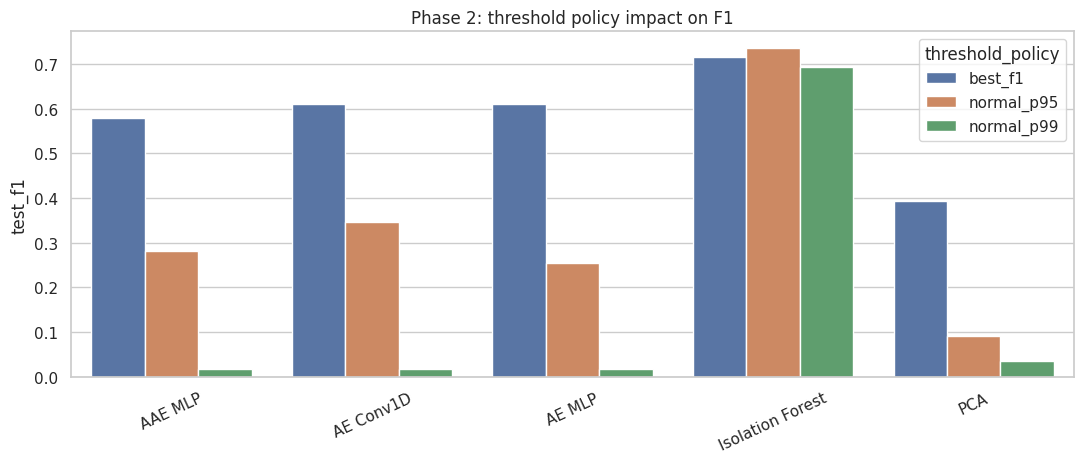

Saved: /content/drive/MyDrive/AM01/results/phase2/figures/threshold_policy_false_alarms.png


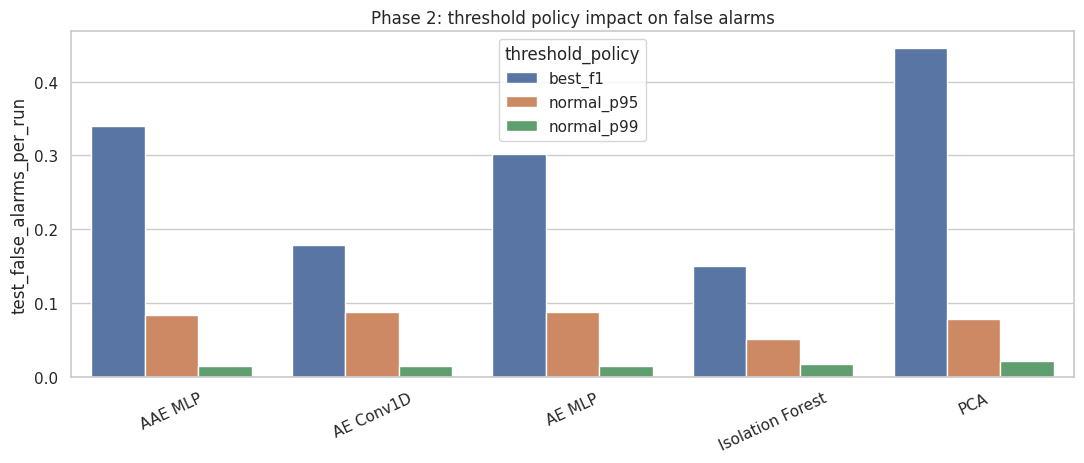

In [5]:
if RUN_THRESHOLD_ANALYSIS:
    rows = []
    threshold_specs = [
        ('best_f1', 'best_f1', 99.0),
        ('normal_p95', 'normal_percentile', 95.0),
        ('normal_p99', 'normal_percentile', 99.0),
    ]
    for run_dir in phase1_run_dirs():
        val = load_scores(run_dir, 'val')
        test = load_scores(run_dir, 'test')
        for label, method, percentile in threshold_specs:
            threshold = select_threshold(val['label'].to_numpy(), val['score'].to_numpy(), method=method, fallback_percentile=percentile)
            metrics = all_metrics(test['label'].to_numpy(), test['score'].to_numpy(), threshold, test['run_id'].to_numpy(), test['start'].to_numpy())
            row = {
                'model_key': model_key_from_dir(run_dir),
                'model': model_label(model_key_from_dir(run_dir)),
                'threshold_policy': label,
                'threshold': threshold,
            }
            row.update({f'test_{k}': v for k, v in metrics.items()})
            rows.append(row)
    threshold_df = pd.DataFrame(rows)
    out = PHASE2_ROOT / 'threshold_analysis'
    out.mkdir(parents=True, exist_ok=True)
    threshold_df.to_csv(out / 'threshold_comparison.csv', index=False)
    threshold_df.to_csv(PHASE2_TABLES / 'threshold_comparison.csv', index=False)
    display(threshold_df[['model', 'threshold_policy', 'test_precision', 'test_recall', 'test_f1', 'test_pr_auc', 'test_false_alarms_per_run']].style.format(precision=3))

    plt.figure(figsize=(11, 4.8))
    ax = sns.barplot(data=threshold_df, x='model', y='test_f1', hue='threshold_policy')
    ax.set_title('Phase 2: threshold policy impact on F1')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    save_fig('threshold_policy_f1.png')
    plt.show()

    plt.figure(figsize=(11, 4.8))
    ax = sns.barplot(data=threshold_df, x='model', y='test_false_alarms_per_run', hue='threshold_policy')
    ax.set_title('Phase 2: threshold policy impact on false alarms')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    save_fig('threshold_policy_false_alarms.png')
    plt.show()
else:
    print('Threshold analysis disattivata.')

## 5. Multi-seed stability

Scrive i risultati in `MyDrive/AM01/results/phase2/multiseed`.

In [6]:
MULTISEED_DIR = PHASE2_ROOT / 'multiseed'
if RUN_MULTI_SEED:
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/isolation_forest.yaml configs/ae_mlp.yaml configs/aae_mlp.yaml configs/ae_conv1d.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{MULTISEED_DIR}" '
        f'--seeds 0 1 2 '
        f'--summary-name multiseed_summary.csv'
    )
else:
    print('Multi-seed disattivato. Se esiste già un summary, verrà letto nella cella successiva.')


$ python scripts/run_experiments.py --configs configs/isolation_forest.yaml configs/ae_mlp.yaml configs/aae_mlp.yaml configs/ae_conv1d.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/phase2/multiseed" --seeds 0 1 2 --summary-name multiseed_summary.csv


,run_name,model,seed,test_f1,test_pr_auc,test_roc_auc,test_false_alarms_per_run
0,isolation_forest_seed0,Isolation Forest,0,0.785,0.827,0.956,0.119
1,isolation_forest_seed1,Isolation Forest,1,0.742,0.715,0.945,0.129
2,isolation_forest_seed2,Isolation Forest,2,0.727,0.837,0.946,0.125
3,ae_mlp_seed0,AE MLP,0,0.582,0.418,0.810,0.312
4,ae_mlp_seed1,AE MLP,1,0.614,0.450,0.850,0.302
5,ae_mlp_seed2,AE MLP,2,0.550,0.384,0.807,0.316
6,aae_mlp_seed0,AAE MLP,0,0.525,0.382,0.769,0.434
7,aae_mlp_seed1,AAE MLP,1,0.575,0.425,0.823,0.317
8,aae_mlp_seed2,AAE MLP,2,0.533,0.374,0.790,0.329
9,ae_conv1d_seed0,AE Conv1D,0,0.541,0.424,0.784,0.348


,model,f1_mean,f1_std,pr_mean,pr_std,fa_mean,fa_std
0,AAE MLP,0.544,0.027,0.394,0.028,0.360,0.064
1,AE Conv1D,0.516,0.040,0.389,0.054,0.310,0.066
2,AE MLP,0.582,0.032,0.418,0.033,0.310,0.007
3,Isolation Forest,0.751,0.030,0.793,0.068,0.125,0.005


Saved: /content/drive/MyDrive/AM01/results/phase2/figures/multiseed_f1_stability.png


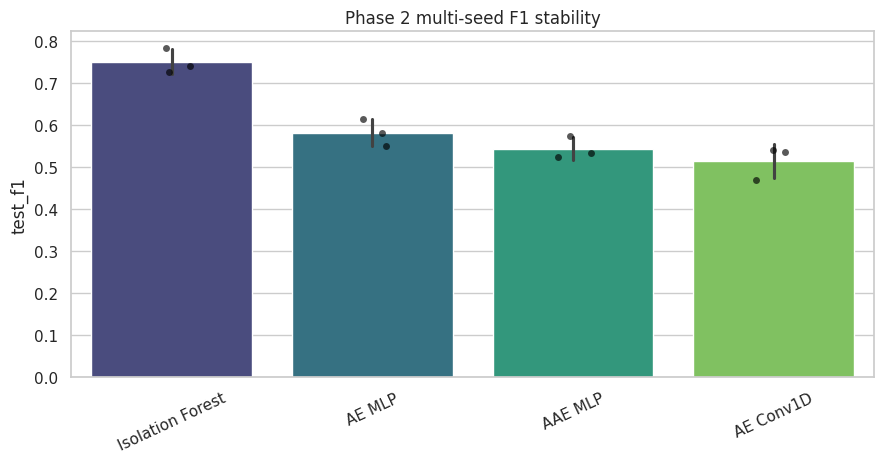

In [7]:
summary_path = MULTISEED_DIR / 'multiseed_summary.csv'
if summary_path.exists():
    multiseed = pd.read_csv(summary_path)
    multiseed['model'] = multiseed['model_type'].map(MODEL_LABELS).fillna(multiseed['model_type'])
    multiseed.to_csv(PHASE2_TABLES / 'multiseed_summary.csv', index=False)
    display(multiseed[['run_name', 'model', 'seed', 'test_f1', 'test_pr_auc', 'test_roc_auc', 'test_false_alarms_per_run']].style.format(precision=3))

    agg = multiseed.groupby('model').agg(
        f1_mean=('test_f1', 'mean'), f1_std=('test_f1', 'std'),
        pr_mean=('test_pr_auc', 'mean'), pr_std=('test_pr_auc', 'std'),
        fa_mean=('test_false_alarms_per_run', 'mean'), fa_std=('test_false_alarms_per_run', 'std'),
    ).reset_index()
    agg.to_csv(PHASE2_TABLES / 'multiseed_mean_std.csv', index=False)
    display(agg.style.format(precision=3))

    plt.figure(figsize=(9, 4.8))
    ax = sns.barplot(data=multiseed, x='model', y='test_f1', errorbar='sd', palette='viridis')
    sns.stripplot(data=multiseed, x='model', y='test_f1', color='black', alpha=0.65, ax=ax)
    ax.set_title('Phase 2 multi-seed F1 stability')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    save_fig('multiseed_f1_stability.png')
    plt.show()
else:
    print(f'Summary non trovato: {summary_path}')

## 6. AAE ablation: lambda e latent dimension

Da eseguire dopo il multi-seed. Scrive in `phase2/aae_ablation`.

In [8]:
AAE_ABLATION_DIR = PHASE2_ROOT / 'aae_ablation'
if RUN_AAE_ABLATION:
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/aae_mlp.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{AAE_ABLATION_DIR}" '
        f'--seeds 42 '
        f'--latent-dims 16 32 '
        f'--lambda-advs 0.001 0.01 0.05 0.1 '
        f'--summary-name aae_ablation_summary.csv'
    )
else:
    print('AAE ablation disattivata. Se esiste già un summary, verrà letto nella cella successiva.')

AAE ablation disattivata. Se esiste già un summary, verrà letto nella cella successiva.


In [9]:
summary_path = AAE_ABLATION_DIR / 'aae_ablation_summary.csv'
if summary_path.exists():
    aae_ablation = pd.read_csv(summary_path)
    aae_ablation.to_csv(PHASE2_TABLES / 'aae_ablation_summary.csv', index=False)
    display(aae_ablation[['run_name', 'latent_dim', 'lambda_adv', 'test_f1', 'test_pr_auc', 'test_event_recall', 'test_false_alarms_per_run']].style.format(precision=3))

    pivot = aae_ablation.pivot_table(index='lambda_adv', columns='latent_dim', values='test_f1', aggfunc='mean')
    plt.figure(figsize=(6.5, 4.5))
    ax = sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
    ax.set_title('AAE ablation: F1 by lambda_adv and latent_dim')
    save_fig('aae_ablation_f1_heatmap.png')
    plt.show()
else:
    print(f'Summary non trovato: {summary_path}')

Summary non trovato: /content/drive/MyDrive/AM01/results/phase2/aae_ablation/aae_ablation_summary.csv


## 7. Preprocessing/loss ablation

Confronta `standard` vs `robust` e `mse` vs `huber` per AE e AAE. Scrive in `phase2/preprocessing_ablation`.

In [10]:
PREPROCESSING_DIR = PHASE2_ROOT / 'preprocessing_ablation'
if RUN_PREPROCESSING_ABLATION:
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/ae_mlp.yaml configs/aae_mlp.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{PREPROCESSING_DIR}" '
        f'--seeds 42 '
        f'--scalers standard robust '
        f'--losses mse huber '
        f'--summary-name preprocessing_ablation_summary.csv'
    )
else:
    print('Preprocessing ablation disattivata. Se esiste già un summary, verrà letto nella cella successiva.')

Preprocessing ablation disattivata. Se esiste già un summary, verrà letto nella cella successiva.


In [11]:
summary_path = PREPROCESSING_DIR / 'preprocessing_ablation_summary.csv'
if summary_path.exists():
    prep = pd.read_csv(summary_path)
    prep['model'] = prep['model_type'].map(MODEL_LABELS).fillna(prep['model_type'])
    prep.to_csv(PHASE2_TABLES / 'preprocessing_ablation_summary.csv', index=False)
    display(prep[['run_name', 'model', 'scaler', 'loss', 'test_f1', 'test_pr_auc', 'test_false_alarms_per_run']].style.format(precision=3))

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=prep, x='scaler', y='test_f1', hue='loss')
    ax.set_title('Preprocessing/loss ablation: F1')
    save_fig('preprocessing_loss_f1.png')
    plt.show()

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=prep, x='scaler', y='test_false_alarms_per_run', hue='loss')
    ax.set_title('Preprocessing/loss ablation: false alarms per run')
    save_fig('preprocessing_loss_false_alarms.png')
    plt.show()
else:
    print(f'Summary non trovato: {summary_path}')

Summary non trovato: /content/drive/MyDrive/AM01/results/phase2/preprocessing_ablation/preprocessing_ablation_summary.csv


## 8. Phase 2 synthesis

Raccoglie i migliori risultati disponibili e crea un breve file markdown.

In [12]:
notes = []
if 'threshold_df' in globals():
    best_thr = threshold_df.loc[threshold_df['test_f1'].idxmax()]
    notes.append(f"Best threshold-policy run: {best_thr['model']} / {best_thr['threshold_policy']} with F1={best_thr['test_f1']:.3f}.")
if 'multiseed' in globals():
    best_seed = multiseed.loc[multiseed['test_f1'].idxmax()]
    notes.append(f"Best multi-seed run: {best_seed['run_name']} with F1={best_seed['test_f1']:.3f}.")
if 'aae_ablation' in globals():
    best_aae = aae_ablation.loc[aae_ablation['test_f1'].idxmax()]
    notes.append(f"Best AAE ablation: lambda={best_aae['lambda_adv']}, latent={best_aae['latent_dim']}, F1={best_aae['test_f1']:.3f}.")
if 'prep' in globals():
    best_prep = prep.loc[prep['test_f1'].idxmax()]
    notes.append(f"Best preprocessing/loss run: {best_prep['run_name']} with F1={best_prep['test_f1']:.3f}.")

summary_md = '# Phase 2 auto-summary\n\n' + '\n'.join(f'- {note}' for note in notes)
(PHASE2_ROOT / 'phase2_auto_summary.md').write_text(summary_md, encoding='utf-8')
display(Markdown(summary_md))
print('Saved:', PHASE2_ROOT / 'phase2_auto_summary.md')

# Phase 2 auto-summary

- Best threshold-policy run: Isolation Forest / normal_p95 with F1=0.736.
- Best multi-seed run: isolation_forest_seed0 with F1=0.785.

Saved: /content/drive/MyDrive/AM01/results/phase2/phase2_auto_summary.md


## 9. Manifest artefatti Phase 2

In [13]:
artifacts = sorted([p for p in PHASE2_ROOT.rglob('*') if p.is_file()])
display(pd.DataFrame({'artifact': [str(p.relative_to(PHASE2_ROOT)) for p in artifacts]}))

,artifact
0,figures/multiseed_f1_stability.png
1,figures/threshold_policy_f1.png
2,figures/threshold_policy_false_alarms.png
3,multiseed/aae_mlp_seed0/config_used.json
4,multiseed/aae_mlp_seed0/dataset_summary.csv
...,...
169,phase2_auto_summary.md
170,tables/multiseed_mean_std.csv
171,tables/multiseed_summary.csv
172,tables/threshold_comparison.csv
